# 📝 Análise de Sessões Prévias

À medida que times se preparam para a corrida no domingo, eles se utilizam dos dados coletados durante o final de semana para tentar elaborar estratégias e planos. Vamos analisar esses dados, com atenção especial para o nosso time...

Nota: para simplificar a análise, vamos levar em consideração que a temperatura e tempo foram iguais em todas as sessões.

Nota 2: Para evitar que a plateia descubra qual foi o GP, os resultados obtidos na corrida de sprint estarão ocultos. Mas considere que foram bons, e similares aos obtidos na qualificatória.

## 📊 Como avaliar a performance?

A maioria dos times do grid não estão no topo. Eles geralmente disputam por posições intermediárias. Como esses times avaliam a performance deles quando não são capazes de vencerem os times maiores?

Ademais, sessões de prática não tem posições. Então como avaliamos performance quando posições não são levadas em consideração?

Na maioria das vezes, times avaliam o ritmo deles, isto é, o tempo de volta. Atingir bons tempos de volta é o fundamental para vencer uma corrida, por mais que não sejam tudo. Ao longo deste final de semana em específico, a correlação entre tempos de volta e posição na sessão de sprint foi de 0.8.

Para que isso seja feito, será utilizado o método `pick_quicklaps` do FastF1, uma vez que esse método filtra apenas voltas dentro do intervalo de 107% da volta mais rápida para a sessão em específico, excluindo voltas deliberadamente lentas da maioria das análises.

## ⚙️ Configurações de ambiente

In [1]:
import os

import fastf1 as ff1
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from fastf1 import plotting
from fastf1.logger import set_log_level

from plots.correlation import plot_scatter
from plots.laps import plot_laptime_correlation_heatmap, plot_team_vs_grid_tyre_wear
from plots.tyres import (
    plot_average_lap_time_by_tyre_wear,
    plot_laptime_distribution_by_team_with_tyre_life,
    plot_tyre_decay_scatter_plot,
)
from processing.laps import get_tyre_life_stats
from tests.comparisons import compare_team_series_to_overall_series
from tests.distribution import ks_test, mann_whitney_u_test
from tests.normality import plot_normality_visual_inspection, shapiro_wilk_test

load_dotenv()

set_log_level("ERROR")
plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")
np.random.seed(123)  # noqa: NPY002

TEAM = os.getenv("TEAM")
EVENT_YEAR = int(os.getenv("EVENT_YEAR"))
ROUND = int(os.getenv("ROUND"))

%matplotlib widget

## 📚 Agregando e limpando dados

### 🗂️ Agregando dados de voltas de todas as sessões antes da corrida durante o final de semana

Os dados de todas as sessões anteriores à corrida serão agregados em um único DataFrame e utilizados para análises.

In [2]:
fp1 = ff1.get_session(EVENT_YEAR, ROUND, "FP1")
sq = ff1.get_session(EVENT_YEAR, ROUND, "SQ")
sprint = ff1.get_session(EVENT_YEAR, ROUND, "S")
quali = ff1.get_session(EVENT_YEAR, ROUND, "Q")
fp1.load(telemetry=False, weather=False)
sq.load(telemetry=False, weather=False)
sprint.load(telemetry=False, weather=False)
quali.load(telemetry=False, weather=False)

In [3]:
fp1_push_laps = fp1.laps.pick_quicklaps()
sq_push_laps = sq.laps.pick_quicklaps()
sprint_push_laps = sprint.laps.pick_quicklaps()
quali_push_laps = quali.laps.pick_quicklaps()

In [4]:
all_laps = pd.concat(
    [
        fp1_push_laps.assign(Session="FP1"),
        sq_push_laps.assign(Session="SQ"),
        sprint_push_laps.assign(Session="Sprint"),
        quali_push_laps.assign(Session="Quali"),
    ],
    ignore_index=True,
)

### ✨ Limpeza de dados e feature engineering

In [5]:
all_laps = all_laps[~all_laps["Deleted"]]  # Removing deleted laps, they are invalid

Convertendo o tempo de volta para segundos para facilitar cálculos.

In [6]:
all_laps["LapTime_s"] = all_laps["LapTime"].dt.total_seconds()

/tmp/ipykernel_234307/2692686783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_laps["LapTime_s"] = all_laps["LapTime"].dt.total_seconds()


In [7]:
# Removing unused featured for easier and lighter calculations
DROP_FEATURES = [
    "Deleted",
    "DeletedReason",
    "FastF1Generated",
    "LapStartTime",
    "LapStartDate",
    "Sector1SessionTime",
    "Sector2SessionTime",
    "Sector3SessionTime",
    "IsPersonalBest",
    "IsAccurate",
    "SpeedFL",
]
all_laps = all_laps.drop(columns=DROP_FEATURES)

Convertendo dados categóricos para inteiros para cálculo de correlações.

In [8]:
session_dummies = pd.get_dummies(all_laps.Session, prefix="Session", dtype=int)
all_laps = pd.concat([all_laps, session_dummies], axis=1)

### 🏷️ Separando dados por composto de pneu

In [9]:
soft = all_laps.pick_compounds("SOFT")
medium = all_laps.pick_compounds("MEDIUM")
hard = all_laps.pick_compounds("HARD")

## 🕰️ Analisando tendências e distribuição de tempos de volta

### ⏳ Analisando tempo de volta geral

Primeiramente, vamos observar quanto tempo uma volta geralmente toma, levando em consdideração todo o grid, independete da sessão e de composto de pneu.

In [10]:
print(
    f"Durante este final de semana, uma volta média levou {all_laps.LapTime_s.mean():.3f} "
    f" +/- {all_laps.LapTime_s.std():.3f} segundos",
)

Durante este final de semana, uma volta média levou 84.157  +/- 2.182 segundos


Dessa forma, meros segundos a cada volta separam vencedores e perdedores.

Depois disso, checamos os tempos de volta para distribuição normal, para enteder quais ferramentas estatísticas poderiam ser utilizadas.

Test statistic 0.9068
P-Value 0.0000
Os dados NÃO parecem normalmente distribuídos.


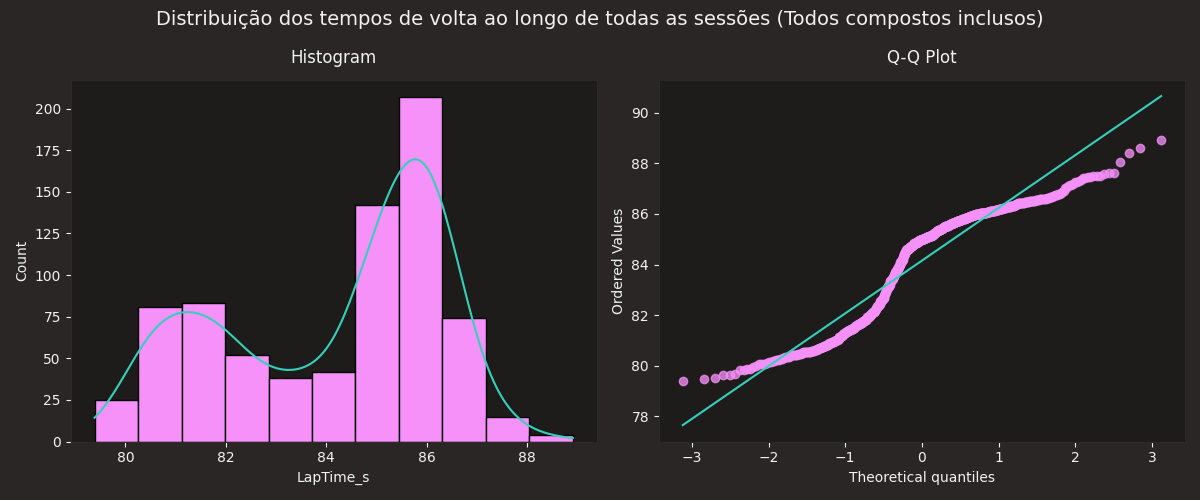

In [11]:
shapiro_wilk_test(all_laps.LapTime_s, language="pt")
plot_normality_visual_inspection(
    all_laps.LapTime_s,
    title="Distribuição dos tempos de volta ao longo de todas as sessões (Todos compostos inclusos)",
)

É possível visualizar que os dados não são normalmente distribuídos. Teremos de usar testes não paramétricos ao analisar tempos de volta neste recorte de dados.

Vamos checar se os resultados são diferentes ao separar por compostos de pneu:

Test statistic 0.8181
P-Value 0.0000
Os dados NÃO parecem normalmente distribuídos.


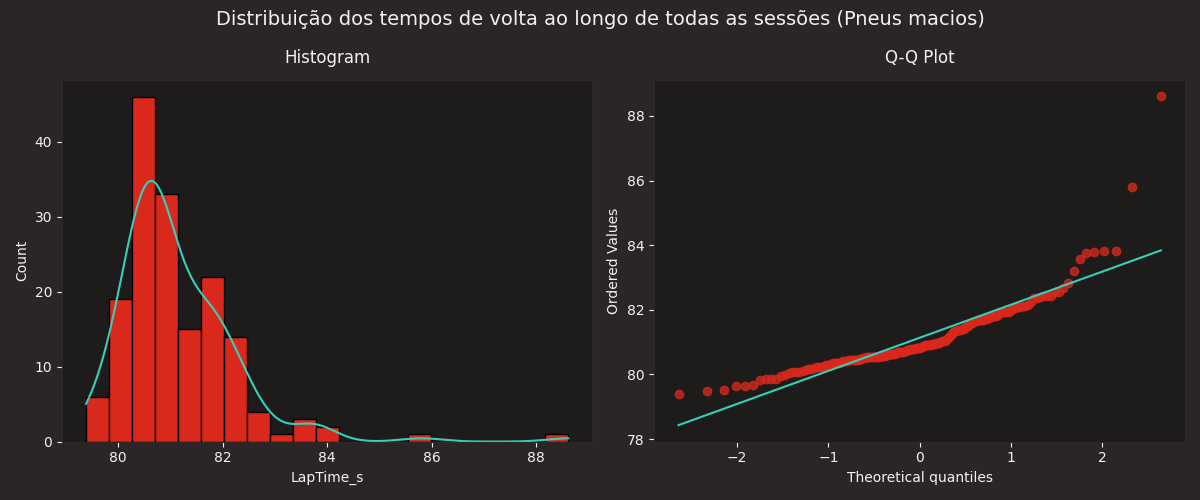

In [12]:
shapiro_wilk_test(soft.LapTime_s, language="pt")
plot_normality_visual_inspection(
    soft.LapTime_s,
    title="Distribuição dos tempos de volta ao longo de todas as sessões (Pneus macios)",
    color=plotting.get_compound_color("soft", session=quali),
)

A alta concentração na área esquerda do gráfico pode ser explicada pelo fato de que compostos macios são projetados para trazer os carros o mais próximo possível aos seus limites de velocidade. Esse composto é usado para stints curtos, como voltas qualificatórias. Em breve, nos aprofundaremos mais nesse composto.

Test statistic 0.8705
P-Value 0.0000
Os dados NÃO parecem normalmente distribuídos.


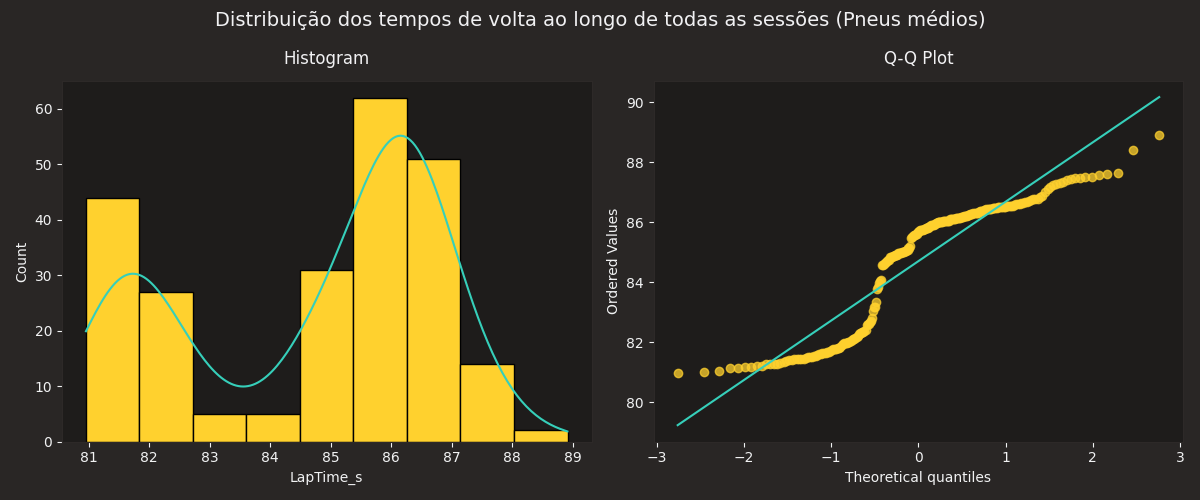

In [13]:
shapiro_wilk_test(medium.LapTime_s, language="pt")
plot_normality_visual_inspection(
    medium.LapTime_s,
    title="Distribuição dos tempos de volta ao longo de todas as sessões (Pneus médios)",
    color=plotting.get_compound_color("medium", session=quali),
)

Curiosamente, a distribuição para os pneus médios possui duas concentrações diferentes. Em breve, nos aprofundaremos mais nessa distribuição.

Test statistic 0.9458
P-Value 0.0000
Os dados NÃO parecem normalmente distribuídos.


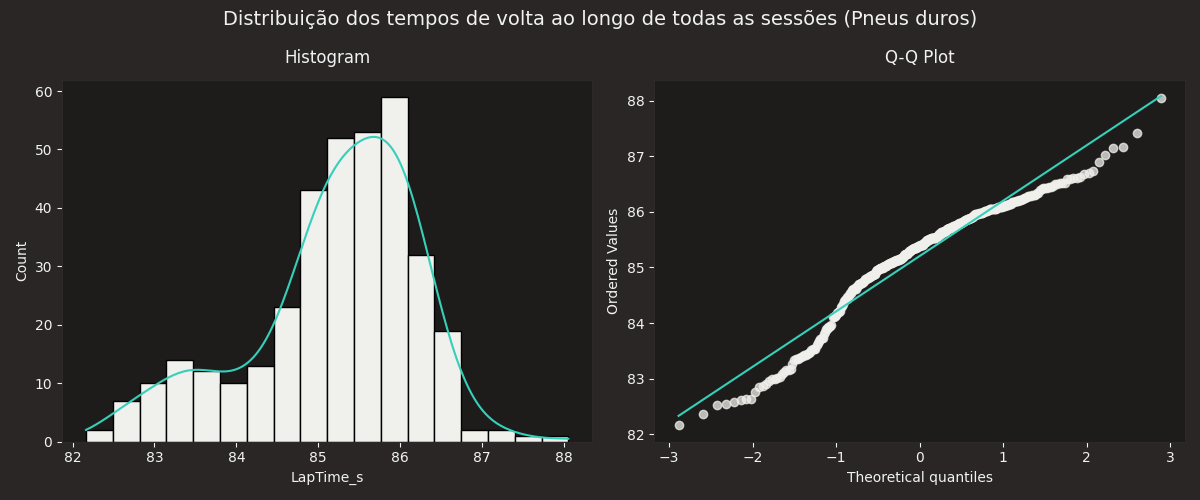

In [14]:
shapiro_wilk_test(hard.LapTime_s, language="pt")
plot_normality_visual_inspection(
    hard.LapTime_s,
    title="Distribuição dos tempos de volta ao longo de todas as sessões (Pneus duros)",
    color=plotting.get_compound_color("hard", session=quali),
)

Contudo, quando se trata de pneus duros, por mais que o teste ainda falhe, a curva se aproxima visualmente muito mais da curva de bell do que para outros compostos. Também nos aprofundaremos nessa distribuição futuramente.

### ⚡ Analisando o tempo de volta em relação às velocidades registradas no primeiro setor intermediário da pista

Como será explicado futuramente neste notebook, a velocidade no primeiro intermédio desse circuito é decisiva para se obter bons tempos de volta. É a parte mais importante do circuito para reduzir tempos de volta.

Test statistic 0.9466
P-Value 0.0000
Os dados NÃO parecem normalmente distribuídos.


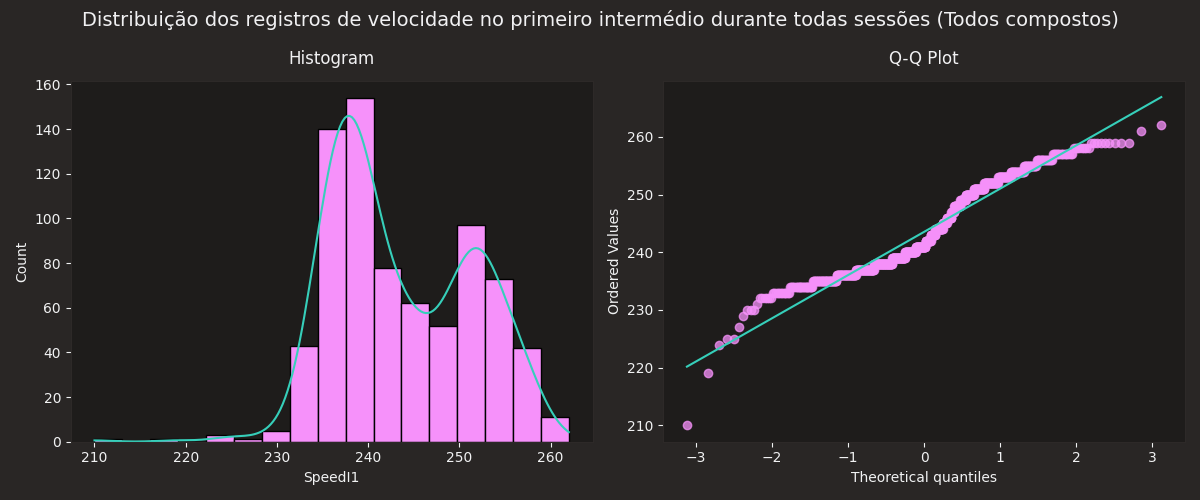

In [15]:
shapiro_wilk_test(all_laps["SpeedI1"], language="pt")
plot_normality_visual_inspection(
    all_laps["SpeedI1"],
    title="Distribuição dos registros de velocidade no primeiro intermédio durante todas sessões (Todos compostos)",
)

As curvas aqui parecem espelhar as tendências dos tempos de volta, mas inversamente.

#### 📈 Com estes valores estão relacionados?

Utilizaremos de scatter plots para visualizar como velocidade e tempos de volta estão relacionados de acordo com o composto do pneu.

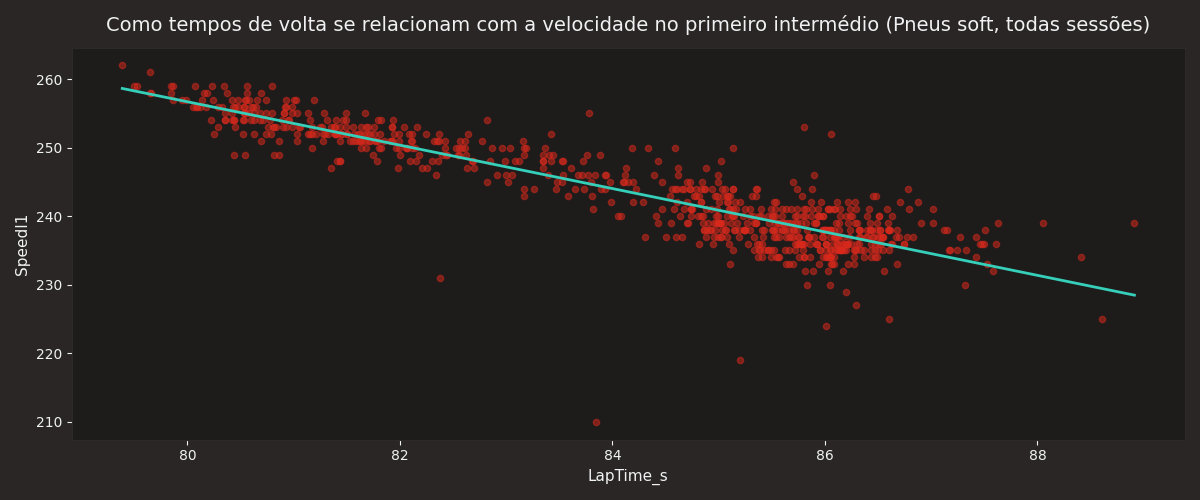

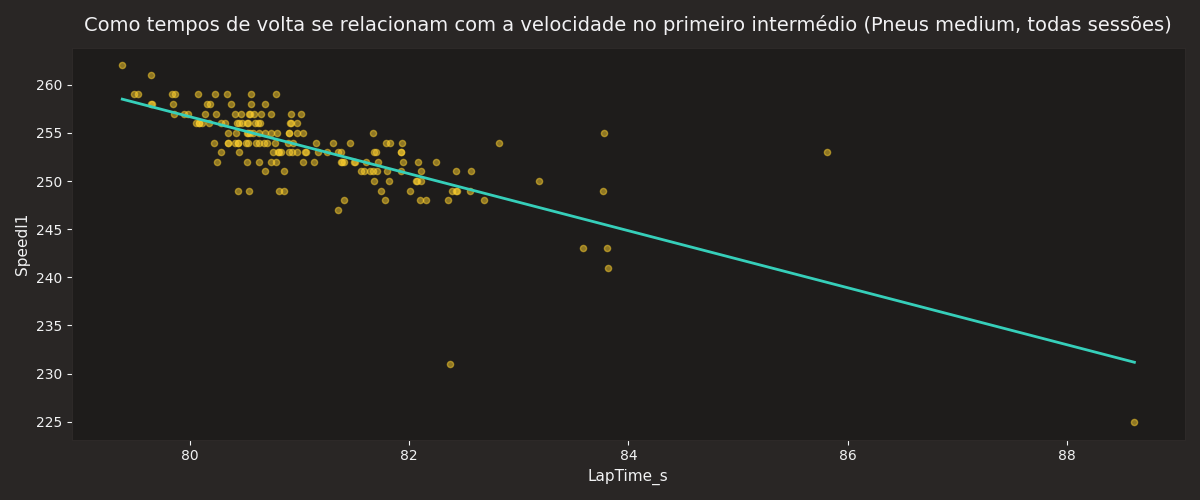

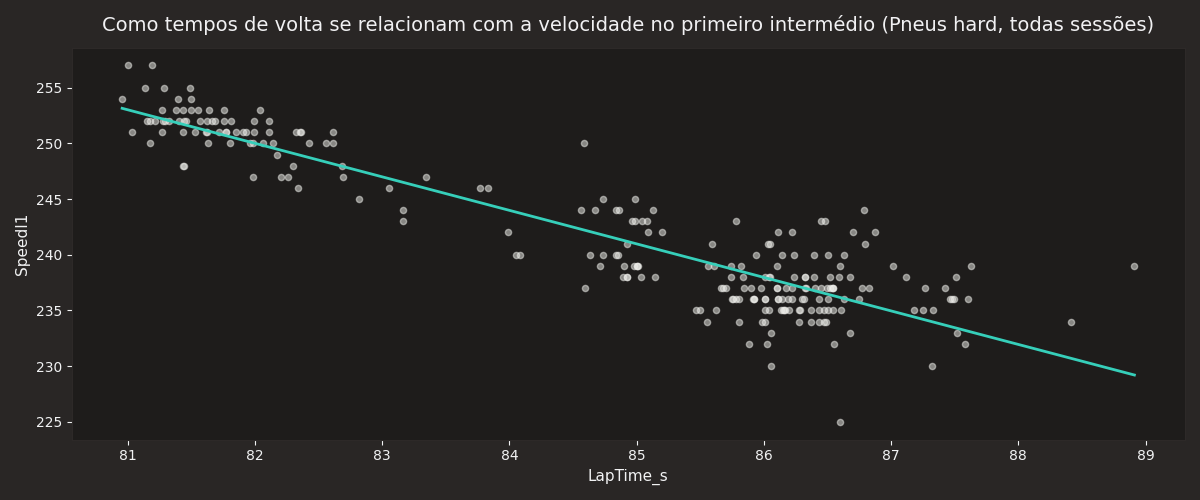

In [16]:
TYRES_CONFIG = ["SOFT", "MEDIUM", "HARD"]

for tyre_config, laps_data in zip(
    TYRES_CONFIG,
    [all_laps, soft, medium, hard],
    strict=False,
):
    plot_scatter(
        laps_data.LapTime_s,
        laps_data.SpeedI1,
        title=f"Como tempos de volta se relacionam com a velocidade no primeiro intermédio (Pneus {tyre_config.lower()}, todas sessões)",
        color=plotting.get_compound_color(tyre_config, quali),
    )

Existe uma alta correlação linear entre as duas variáveis ao analisar o scatter plot visualmente.

## 🛞 Analisando compostos de pneu diferentes

O gerenciamento de pneus é uma das áreas mais cruciais para se obter sucesso na Fórmula 1. Como será explicado em breve, nesse GP em específico, foi uma grande parte do que definiiu as posições finais.

À medida que pilotos completam voltas, quantidade de desgaste do pneu aumenta, fazendo com que os pneus, em tese, perdam aderência, assim aumentando os tempos de volta, sobretudo em circuitos focados em curvas. Contudo, pneus "frios", isto é, fora da temperatura de atuação ideal, também não oferecem boa aderência. Os pneus precisam esquentar na pista.

Dessa forma, a maioria dos compostos possuem uma janela de atuação ótima, balanceando temperatura e desgaste.

### 🟡 Analyzing Medium Tyre Compound influence on Lap Time

/home/jvvc/cesar-beat-f1-workshop/src/plots/tyres.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)
/home/jvvc/cesar-beat-f1-workshop/src/plots/tyres.py:76: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


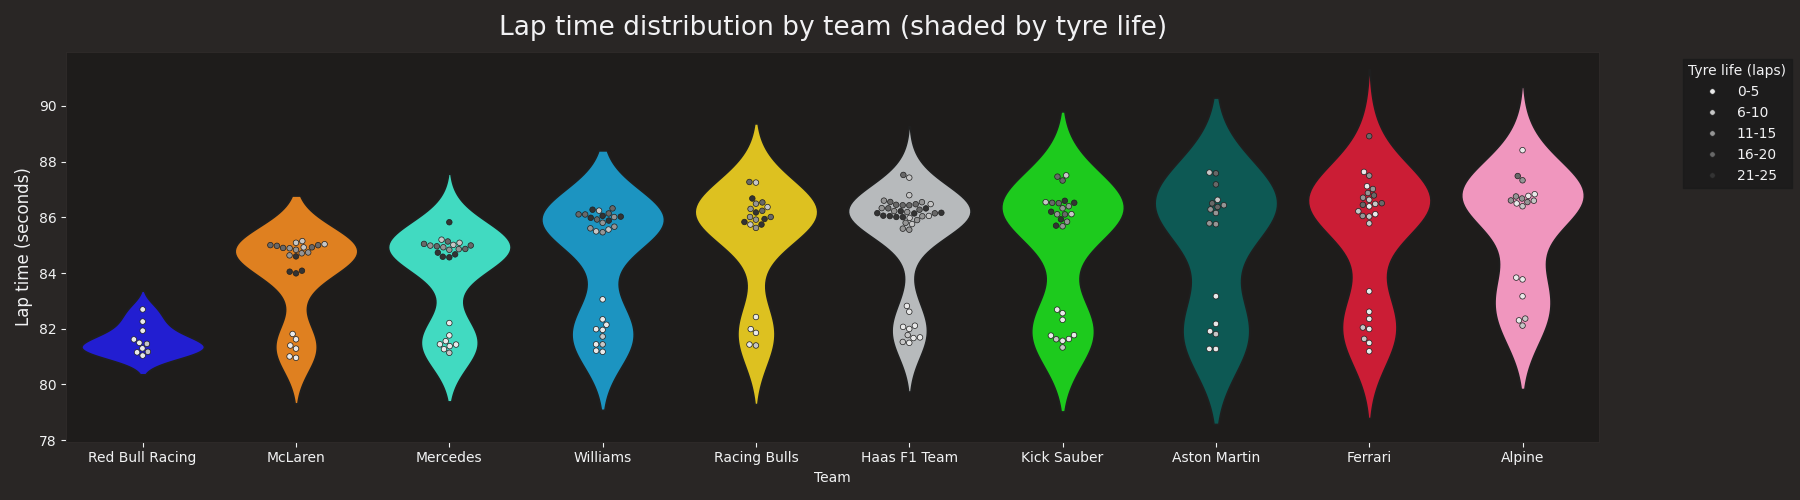

In [17]:
plot_laptime_distribution_by_team_with_tyre_life(medium, quali)

It is possible to notice that most teams follow similar distributions for Medium Tyres. Keep in mind, however, that this is not a perfect comparison of lap times for a race since the data aggregates all types of sessions.

In [18]:
compare_team_series_to_overall_series(
    mann_whitney_u_test,
    medium,
    TEAM,
    "LapTime_s",
    language="pt",
)

Comparando contra Red Bull Racing
========== Mann-Whitney U ==========
Test statistic 201.0000
P-Value 0.0023
NÃO existe diferenca estatisticamente significativa entre as séries.

Comparando contra Kick Sauber
========== Mann-Whitney U ==========
Test statistic 171.0000
P-Value 0.0040
NÃO existe diferenca estatisticamente significativa entre as séries.

Comparando contra Racing Bulls
========== Mann-Whitney U ==========
Test statistic 94.0000
P-Value 0.0002
NÃO existe diferenca estatisticamente significativa entre as séries.

Comparando contra Alpine
========== Mann-Whitney U ==========
Test statistic 108.0000
P-Value 0.0063
NÃO existe diferenca estatisticamente significativa entre as séries.

Comparando contra Mercedes
========== Mann-Whitney U ==========
Test statistic 277.5000
P-Value 0.6599
EXISTE uma diferença estatisticamente significativa entre as séries.

Comparando contra Aston Martin
========== Mann-Whitney U ==========
Test statistic 117.0000
P-Value 0.0221
NÃO existe difere

This test is highly insensitive to variance, focusing in shifts in locations (medians or means). Therefore, it highlights how complex trying to analyze F1 can be: even between the fastest and the slowest teams on the grid, according to the Mann-Whitney U test, it still is not possible to detect a difference between the lap time that is statistically significant regarding to measures of central tendency.

Notably, however, there is an excpetion for team #3.

In [19]:
compare_team_series_to_overall_series(ks_test, medium, TEAM, "LapTime_s", language="pt")

Comparando contra Red Bull Racing
========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.7500
P-Value: 0.0002
EXISTE uma diferença estatisticamente significativa entre as séries.

Comparando contra Kick Sauber
========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.6667
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.

Comparando contra Racing Bulls
========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.7727
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.

Comparando contra Alpine
========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.6667
P-Value: 0.0001
EXISTE uma diferença estatisticamente significativa entre as séries.

Comparando contra Mercedes
========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.1500
P-Value: 0.8853
NÃO existe diferença es

However, when testing using Kolmogorov-Smirnov, it was possible to identify differences between most of the grid, with the notable exception of team 3. This tests focuses on extracting the maximum vertical distance between two cumulative curves, evaluating overall goodness-of-fit. It is more sensitive to shifts in variance or overall shape. Therefore, the main statistically significant difference between teams' laps in this weekend lies on consistency rather than mean or median pace. Keep this in mind as we analyze the race results!

#### 🟡 How do these tyres influence on lap time and speed?

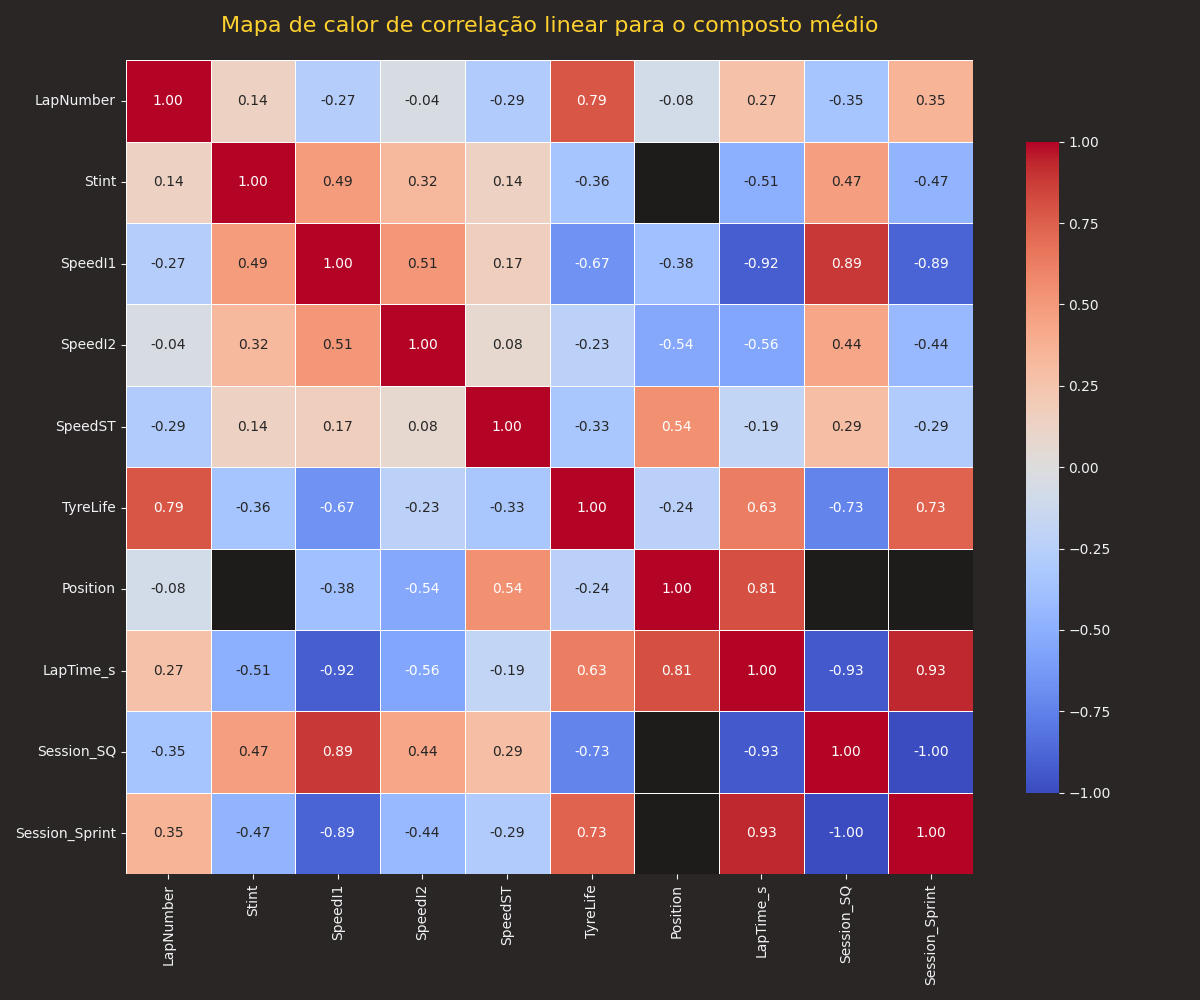


--- Correlations with lap time ---
Session_SQ        -0.93
Session_Sprint     0.93
SpeedI1           -0.92
Position           0.81
TyreLife           0.63
SpeedI2           -0.56
Stint             -0.51
LapNumber          0.27
SpeedST           -0.19
Name: LapTime_s, dtype: object


In [20]:
plot_laptime_correlation_heatmap(
    medium,
    title="Mapa de calor de correlação linear para o composto médio",
    title_color=plotting.get_compound_color("medium", quali),
)

Ao analisar os fatores com maior correlação linear com o tempo de volta usando compostos médios, foi possível detectar que as maiores correlações eram associadas com o tipo de sessão, destacando o quão diferentes voltas podem ser em sessões diferentes.

A velocidade registrada no primeiro setor intermediário foi a característica mais decisiva para extrair bons tempos de volta. Essa velocidade é altamente correlacionada com o desgaste dos pneus (TyreLife), apresentando um valor de -0.67. Isso é esperado, uma vez que a aderência dos pneus é um dos componentes cruciais para se obter alta velocidade.

Como esperado, há uma alta correlação entre tempo de voltas e posição final (0.81).

Finalmnete, a vida dos pneus possui uma correlação direta com o tempo de volta de 0.63 ao utilizar pneus médios, demonstrando seu desgaste de aderência.

Esses dados são cruciais para projetar um plano de corrida e decidir aonde focar na pista.

#### 🟡 Medindo o desgaste dos pneus médios

Agora, vamos usar dados para entender como os pneus se desgastam. Isso é crucial para determinar quando realizar pit stops.

Ao analisar a performance dos pneus, é crucial, conforme ilustado no mapa anterior, separar por tipos de sessão. Ademais, focar mais na tendência do delta dos tempos de volta do que a saída bruta de tempo, uma vez que diferentes sessÕes tendem a apresentar tempos de volta mais curtos (qualificatórias).

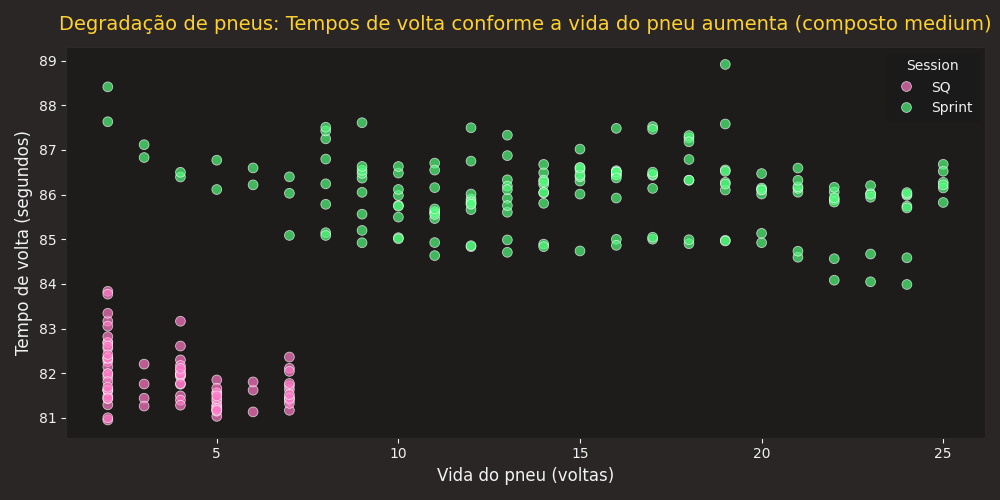

In [21]:
plot_tyre_decay_scatter_plot(
    medium,
    title_color=plotting.get_compound_color("medium", quali),
    language="pt",
)

É posssível perceber, pelos gráficos, que a perda de aderência dos pneus médios não tem sido muito grave, tem sido bastante controlada, apesar de haver uma certa perda de performance. Isso também reflete as estratégias dos pilotos para conservar seus pneus.

In [22]:
mann_whitney_u_test(
    medium[medium.Session_SQ == 1]["LapTime_s"],
    medium[medium.Session_Sprint == 1]["LapTime_s"],
)
print()
ks_test(
    medium[medium.Session_SQ == 1]["LapTime_s"],
    medium[medium.Session_Sprint == 1]["LapTime_s"],
)

========== Mann-Whitney U ==========
Test statistic 0.0000
P-Value 0.0000
There is NOT a statistically significant difference between the series.

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 1.0000
P-Value: 0.0000
There IS a statistically significant difference between the series.


(np.float64(1.0), np.float64(4.630625161998186e-65))

Mais uma vez, medidas de tendência centrais entre os dois tipos de sessão são similares, enquanto as distribuições em si possuem formatos com diferença estatisticamente significante no que se refere a tempos de volta.

Ter acesso a dados de uma sessão de sprint é muito útil, uma vez que, apesar de mais curta, ainda é uma sessão de corrida! Vamos focar nos dados coletados para essa sessão para tentar estimar o desgaste de pneus em um cenário mais próximo da realidade da corrida.

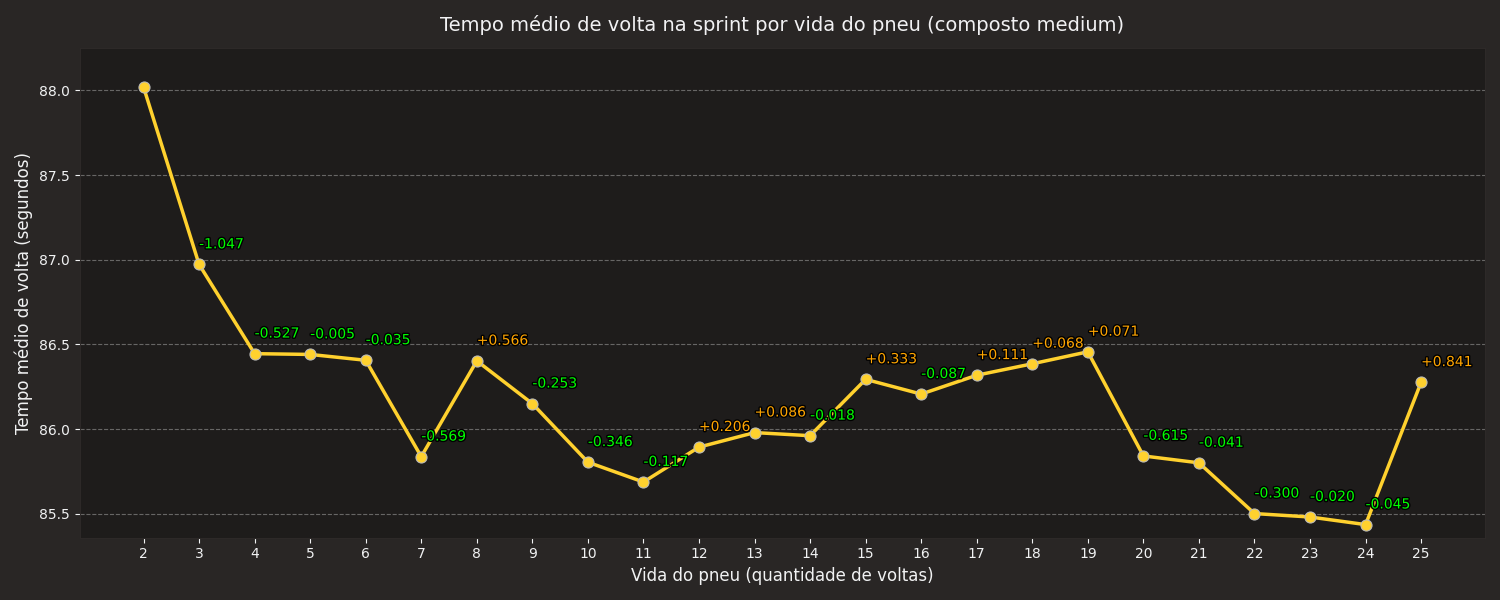

In [23]:
mean_laps_by_life_medium = get_tyre_life_stats(medium, session="Sprint")
plot_average_lap_time_by_tyre_wear(
    mean_laps_by_life_medium,
    "Medium",
    sprint,
    language="pt",
)

Dessa forma, os dados sugerem que a janela ótima de performance para pneus médios se situa no intervalo de 8 a 15 voltas, e então há uma queda de tempo próximo ao final do limite de uso (25), possivelmente devida aos pilotos tentarem extrair o máximo de aderência restante nos pneus antes de trocá-los.

Agora, vamos observar como a queda de performance se dá para o nosso time.

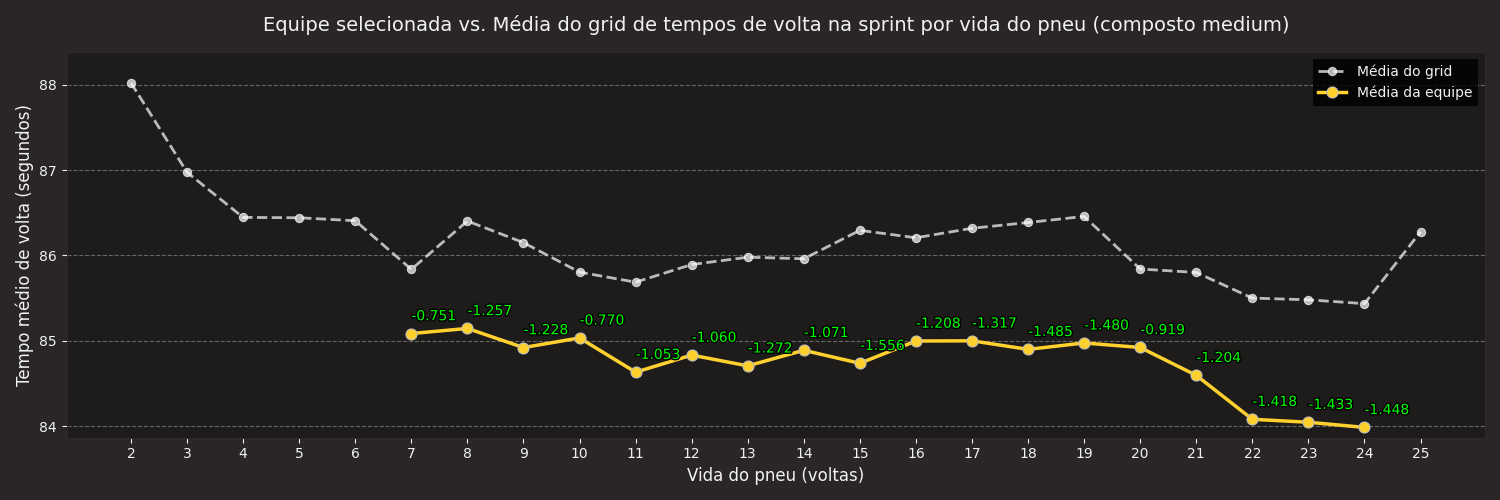

In [24]:
team_mean_laps_by_life_medium = get_tyre_life_stats(
    medium.pick_teams(TEAM),
    session="Sprint",
)
plot_team_vs_grid_tyre_wear(
    mean_laps_by_life_medium,
    team_mean_laps_by_life_medium,
    "MEDIUM",
    sprint,
    language="pt",
)

In [25]:
print(
    f"Média geral do tempo de volta: {mean_laps_by_life_medium.LapTime_s.mean():.3f} "
    f"+/- {mean_laps_by_life_medium.LapTime_s.std():.3f}",
)

Média geral do tempo de volta: 86.167 +/- 0.545


In [26]:
print(
    f"Média do tempo de volta da nossa equipe: {team_mean_laps_by_life_medium.LapTime_s.mean():.3f} "
    f" +/- {team_mean_laps_by_life_medium.LapTime_s.std():.3f}",
)

Média do tempo de volta da nossa equipe: 84.751  +/- 0.359


Não apenas possuímos um tempo médio de volta menor, mas o desvio padrão ao longo da corrida também é menor, demonstrando consistência. Ademais, pelo gráfico, é possível ver que há menos tendências de aumento de tempo de volta ao longo do uso dos pneus. Contudo, os testes ainda trazem os mesmos resultados:

In [27]:
mann_whitney_u_test(
    mean_laps_by_life_medium.LapTime_s,
    team_mean_laps_by_life_medium.LapTime_s,
    language="pt",
)
print()
ks_test(
    mean_laps_by_life_medium.LapTime_s,
    team_mean_laps_by_life_medium.LapTime_s,
    language="pt",
)

========== Mann-Whitney U ==========
Test statistic 432.0000
P-Value 0.0000
NÃO existe diferenca estatisticamente significativa entre as séries.

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 1.0000
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.


(np.float64(1.0), np.float64(5.6545554966993126e-12))

### ⚪ Analyzing Hard Tyre Compound influence on LapTime

/home/jvvc/cesar-beat-f1-workshop/src/plots/tyres.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)
/home/jvvc/cesar-beat-f1-workshop/src/plots/tyres.py:76: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


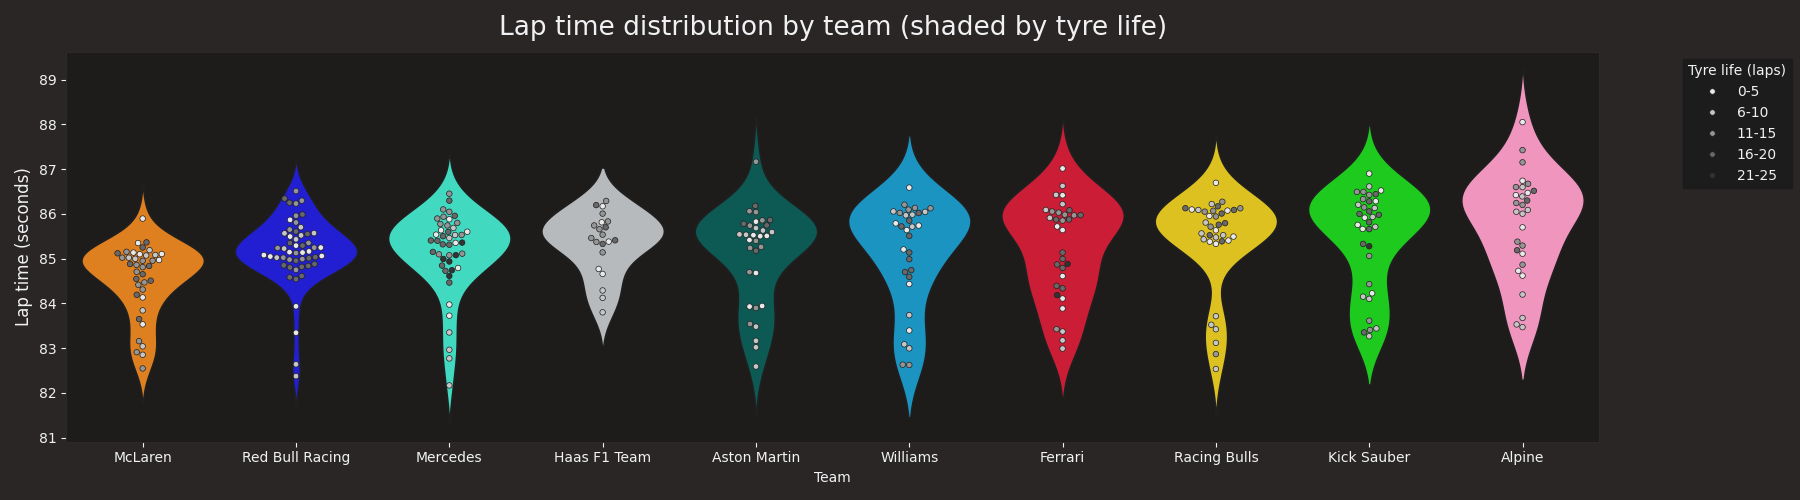

In [28]:
plot_laptime_distribution_by_team_with_tyre_life(hard, quali)

Enquanto o gráfico para pneus médios se concentrava tanto em tempos de volta menores, com menos desgaste, quanto tempos de volta maiores, com maior desgaste, a concentração para pneus duros se dá majoritariamente em voltas de maior tempo, com alto desgaste.

In [29]:
compare_team_series_to_overall_series(
    mann_whitney_u_test,
    hard,
    TEAM,
    "LapTime_s",
    language="pt",
)

Comparando contra Red Bull Racing
========== Mann-Whitney U ==========
Test statistic 532.5000
P-Value 0.0001
NÃO existe diferenca estatisticamente significativa entre as séries.

Comparando contra Kick Sauber
========== Mann-Whitney U ==========
Test statistic 309.0000
P-Value 0.0001
NÃO existe diferenca estatisticamente significativa entre as séries.

Comparando contra Racing Bulls
========== Mann-Whitney U ==========
Test statistic 228.0000
P-Value 0.0000
NÃO existe diferenca estatisticamente significativa entre as séries.

Comparando contra Alpine
========== Mann-Whitney U ==========
Test statistic 212.0000
P-Value 0.0000
NÃO existe diferenca estatisticamente significativa entre as séries.

Comparando contra Mercedes
========== Mann-Whitney U ==========
Test statistic 451.0000
P-Value 0.0001
NÃO existe diferenca estatisticamente significativa entre as séries.

Comparando contra Aston Martin
========== Mann-Whitney U ==========
Test statistic 342.0000
P-Value 0.0007
NÃO existe difer

In [30]:
compare_team_series_to_overall_series(
    ks_test,
    hard,
    TEAM,
    "LapTime_s",
    language="pt",
)

Comparando contra Red Bull Racing
========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.3933
P-Value: 0.0012
EXISTE uma diferença estatisticamente significativa entre as séries.

Comparando contra Kick Sauber
========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.6374
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.

Comparando contra Racing Bulls
========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.7799
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.

Comparando contra Alpine
========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.6295
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.

Comparando contra Mercedes
========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.5009
P-Value: 0.0000
EXISTE uma diferença es

Mais uma vez, os resultados dos testes se repetem.

#### ⚪ How do these tyres influence on lap time?

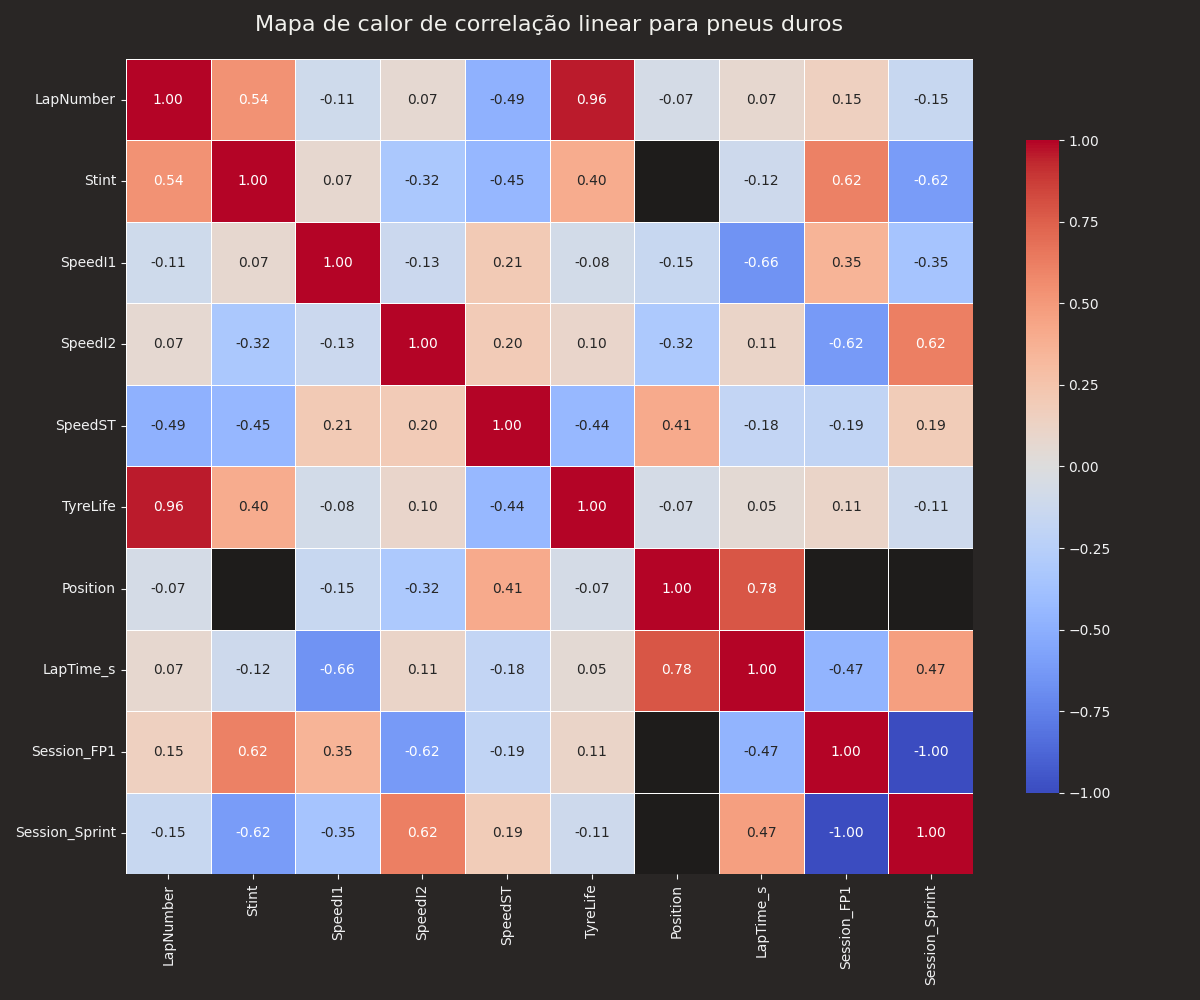


--- Correlations with lap time ---
Position           0.78
SpeedI1           -0.66
Session_FP1       -0.47
Session_Sprint     0.47
SpeedST           -0.18
Stint             -0.12
SpeedI2            0.11
LapNumber          0.07
TyreLife           0.05
Name: LapTime_s, dtype: object


In [ ]:
plot_laptime_correlation_heatmap(
    hard,
    title="Mapa de calor de correlação linear para pneus duros",
    title_color=plotting.get_compound_color("hard", quali),
)

Mais uma vez, a velocidade registrada no primeiro setor intermediário ainda é importante, contudo, não tanto quanto para pneus médios. O desgaste dos pneus duros parece não ter nenhuma correlação linear com essa velocidade. Há, contudo, uma correlação negativa com a velocidade nas retas (-0.44). Isto é, quanto maior a vida dos pneus, menor a velocidade.

Porém, vale salientar que para tempos de volta, não é tão importante (-0.18) quanto outros setores.

Não há indicação de nenhum tipo de correlação linear entre o tempo de vida dos pneus duros com o tempo de volta. Vale salientar, contudo, que a velocidade nas retas ainda é uma métrica bastante relevante a ser considerada para oportunidades de ultrapassagem em certos cirtcuitos. Então, é sempre bom manter essa informação em mente ao definir sua estratégia de pneus.

#### ⚪ Analyzing Hard Tyre Compound performance decay

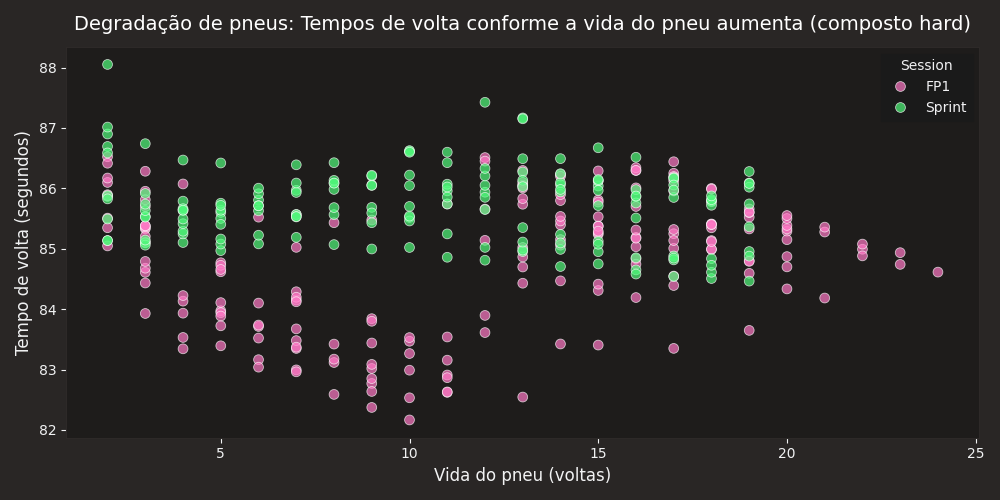

In [32]:
plot_tyre_decay_scatter_plot(hard, language="pt")

Mais uma vez, o gráfico parece estar verticalmetne separado por sessões.

In [ ]:
mann_whitney_u_test(
    hard[hard.Session_FP1 == 1]["LapTime_s"],
    hard[hard.Session_Sprint == 1]["LapTime_s"],
    language="pt",
)
print()
ks_test(
    hard[hard.Session_FP1 == 1]["LapTime_s"],
    hard[hard.Session_Sprint == 1]["LapTime_s"],
    language="pt",
)

========== Mann-Whitney U ==========
Test statistic 7686.0000
P-Value 0.0000
There is NOT a statistically significant difference between the series.

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.4083
P-Value: 0.0000
There IS a statistically significant difference between the series.


(np.float64(0.4082934609250399), np.float64(1.0332382975397134e-13))

Assim como para o composto médio, as medidas centrais são similares enquanto a forma das distribuições são estatiscametne diferentes.

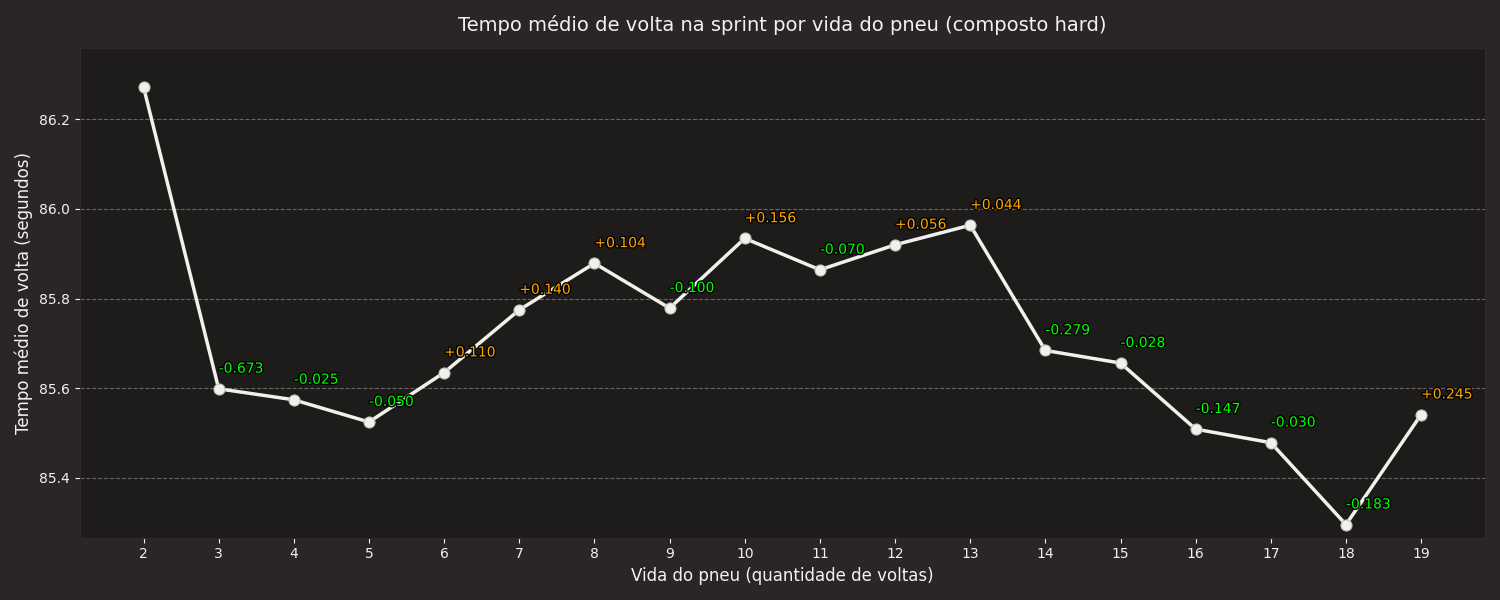

In [34]:
hard_mean_laps_by_life = get_tyre_life_stats(hard, session="Sprint")
plot_average_lap_time_by_tyre_wear(
    hard_mean_laps_by_life,
    "Hard",
    sprint,
    language="pt",
)

Por mais que a performance comece a deteriorar após a quinta volta, os deltas são menores, isso é, há menos variância no tempo de volta. Vamos calcular a diferença entre o desvio padrão dos pneus macios e pneus duros para o grid como um todo.

In [35]:
decrease_of_std = (
    mean_laps_by_life_medium.LapTime_s.std() - hard_mean_laps_by_life.LapTime_s.std()
)
print(
    f"Pneus duros tem uma queda de {decrease_of_std:.3f} em desvio padrão",
    "quando comparados com pneus médios.",
)

Pneus duros tem uma queda de 0.315 em desvio padrão quando comparados com pneus médios.


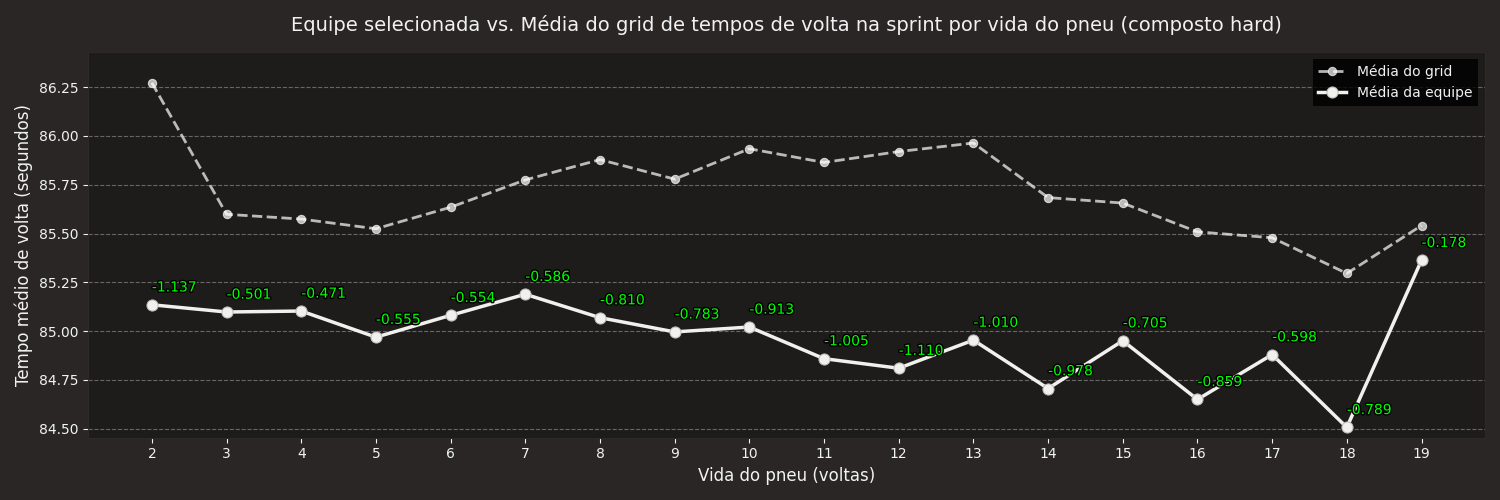

In [36]:
team_mean_laps_by_life_hard = get_tyre_life_stats(
    hard.pick_teams(TEAM),
    session="Sprint",
)
plot_team_vs_grid_tyre_wear(
    hard_mean_laps_by_life,
    team_mean_laps_by_life_hard,
    "HARD",
    sprint,
    language="pt",
)

In [37]:
print(
    f"Tempo de volta médio do grid: {hard_mean_laps_by_life.LapTime_s.mean():.3f} "
    f"+/- {hard_mean_laps_by_life.LapTime_s.std():.3f}",
)

Tempo de volta médio do grid: 85.716 +/- 0.231


In [38]:
print(
    f"Tempo de volta médio da nossa equipe: {team_mean_laps_by_life_hard.LapTime_s.mean():.3f} "
    f" +/- {team_mean_laps_by_life_hard.LapTime_s.std():.3f}",
)

Tempo de volta médio da nossa equipe: 84.963  +/- 0.206


Mais uma vez, ao analizar a performance da nossa equipe em relação grid, é possível observar uma média menor no tempo de volta médio e uma consistência equiparável. Também há menos subidas nos tempos de volta, e uma tendência em direções completamente diferentes da volta 7 até a 12.

In [39]:
mann_whitney_u_test(
    hard_mean_laps_by_life.LapTime_s,
    hard_mean_laps_by_life.LapTime_s,
    language="pt",
)
print()
ks_test(
    team_mean_laps_by_life_hard.LapTime_s,
    team_mean_laps_by_life_hard.LapTime_s,
    language="pt",
)

========== Mann-Whitney U ==========
Test statistic 162.0000
P-Value 1.0000
EXISTE uma diferença estatisticamente significativa entre as séries.

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NÃO existe diferença estatisticamente significativa entre as séries.


(np.float64(0.0), np.float64(1.0))

Os testes também retornam resultados diferentes do que os pneus médios: HÁ uma diferença estatisticamente significante entre as medidas centrais das séries, enquanto a distribuição parece ser a mesma.

### 🔴 Analisando a influência do composto macio no tempo de volta

/home/jvvc/cesar-beat-f1-workshop/src/plots/tyres.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)
/home/jvvc/cesar-beat-f1-workshop/src/plots/tyres.py:76: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


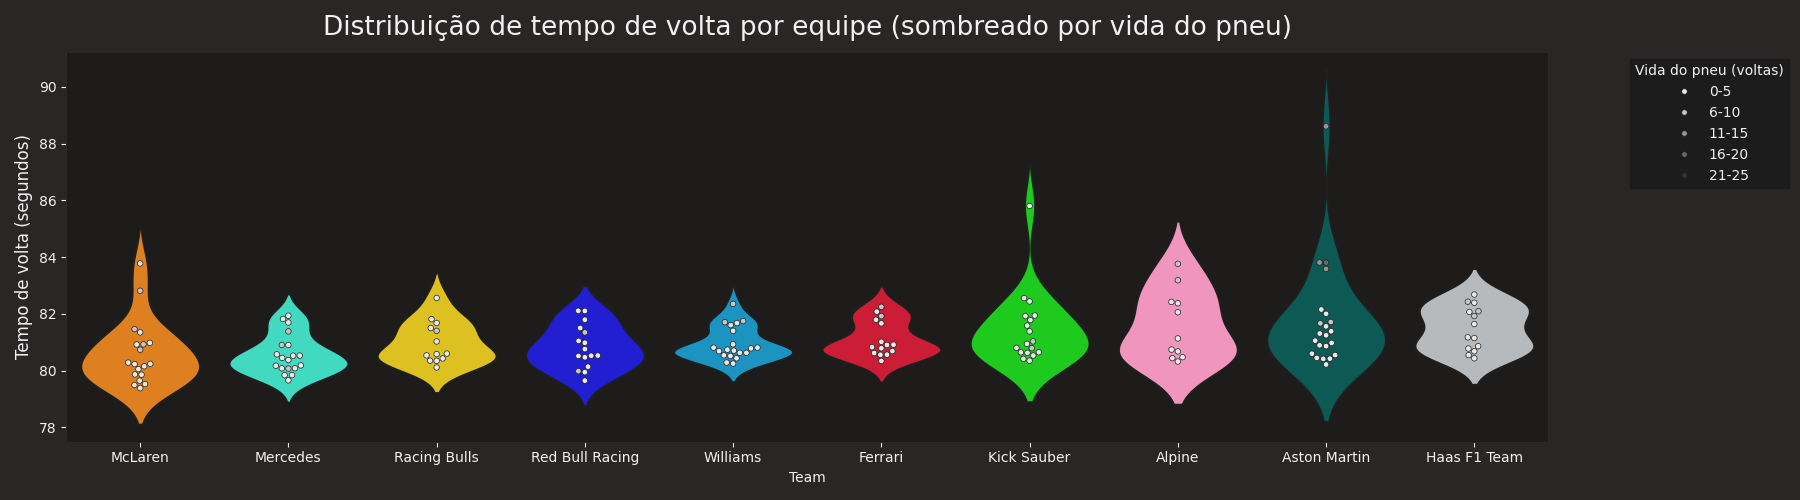

In [40]:
plot_laptime_distribution_by_team_with_tyre_life(soft, quali, language="pt")

Enquanto o gráfico para pneus duros estava concentrado em pneus mais desgastados com maior tempo de volta, e os médios tinham duas concentrações, os macios se concentram em pneus com pouco tempo de vida, para tempos de volta curtos.

Devido ao baixo número de dados referentes a pneus macios macios, não iremos fazer testes de hipótese, uma vez que perdem precisão com uma quantidade menor de dados.

#### 🔴 Como esse composto influencia no tempo de volta?

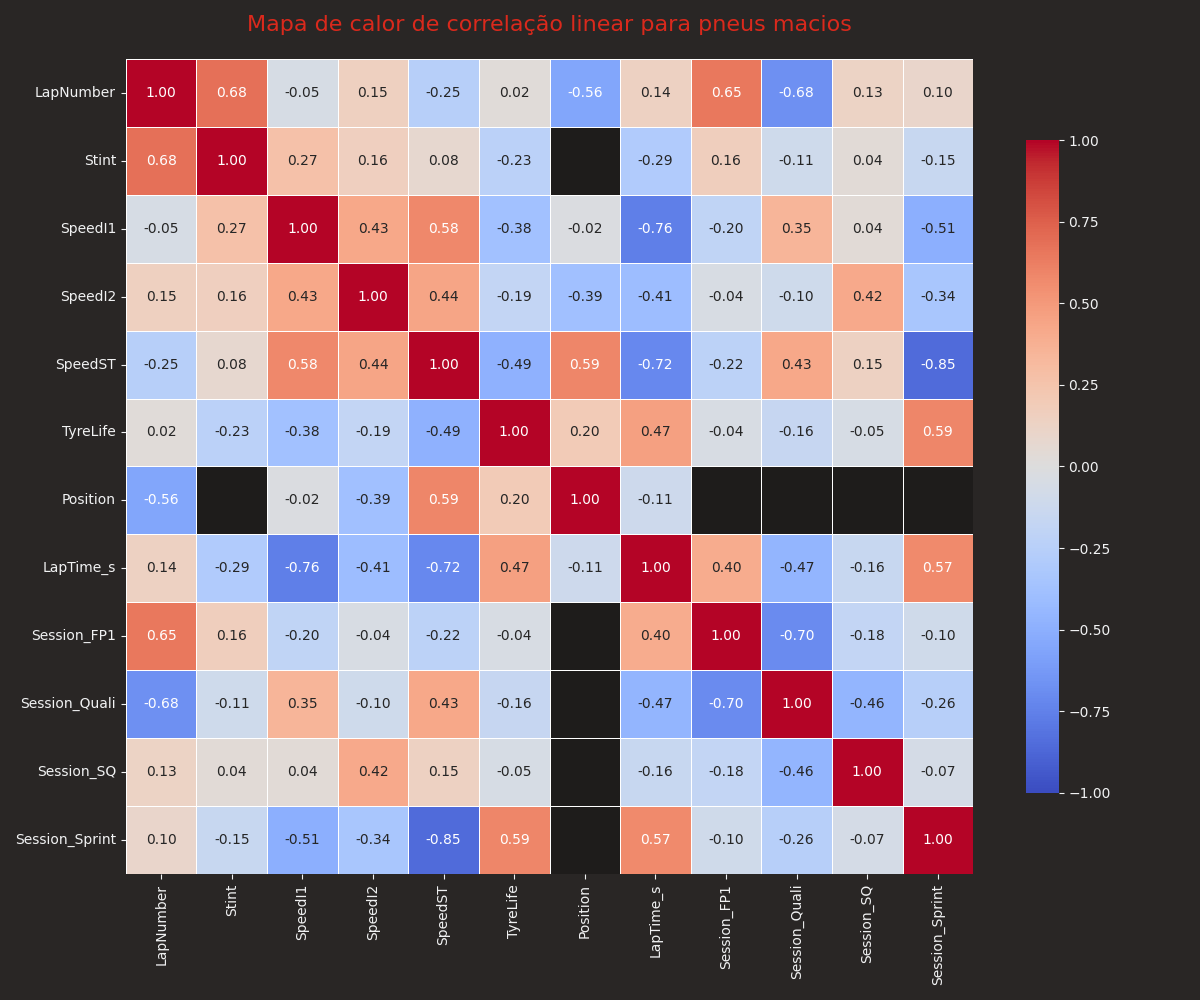


--- Correlations with lap time ---
SpeedI1           -0.76
SpeedST           -0.72
Session_Sprint     0.57
Session_Quali     -0.47
TyreLife           0.47
SpeedI2           -0.41
Session_FP1        0.40
Stint             -0.29
Session_SQ        -0.16
LapNumber          0.14
Position          -0.11
Name: LapTime_s, dtype: object


In [49]:
plot_laptime_correlation_heatmap(
    soft,
    title="Mapa de calor de correlação linear para pneus macios",
    title_color=plotting.get_compound_color("soft", quali),
)

Velocidade registrada no primeiro setor intermediário da pista, mais uma vez, possuiu alta correlação com tempos de volta nos pneus macios, e dessa vez, a velocidade em linhas retas também teve uma correlação similar.

Também há uma correlação negativa moderada entre o desgaste dos pneus e ambas as métricas anteriores (-0.49 e -0.38).

Também há uma correlação linear direta entre maior desgaste dos pneus e aumento nos tempos de volta.

#### 🔴 Medindo o desgaste dos pneus macios

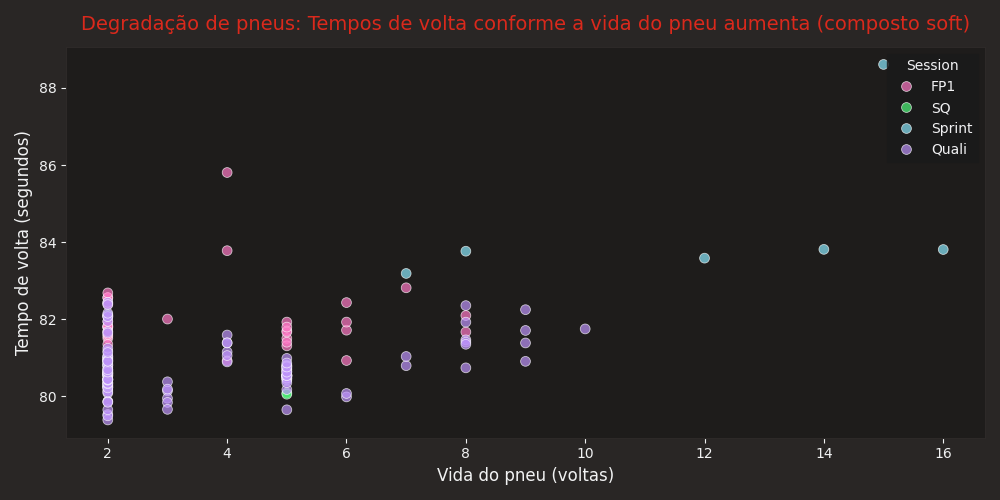

In [ ]:
plot_tyre_decay_scatter_plot(
    soft,
    title_color=plotting.get_compound_color("soft", quali),
    language="pt",
)

O gráfico de degradação dos pneus é mais espaçado, e tempos a partir da volta 6 já aparentam haver grande incremento.

Pneus macios também foram usados em todas as sessões deste final de semana.

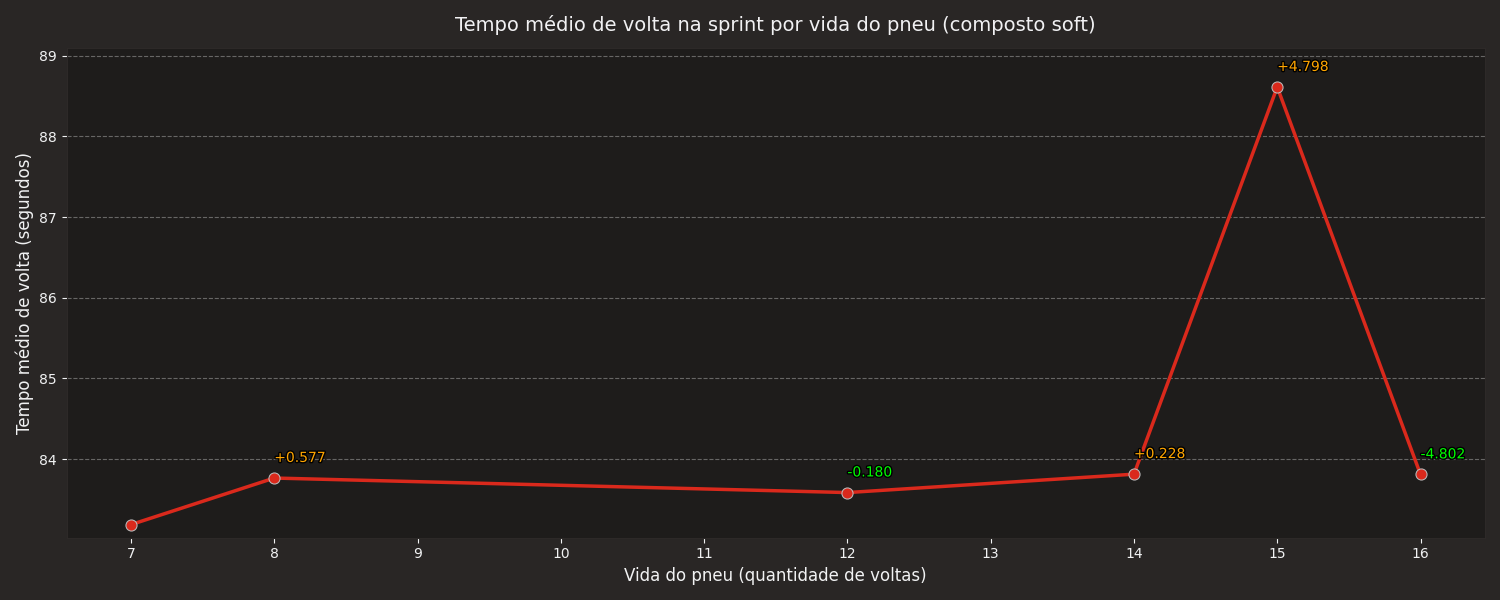

In [ ]:
mean_laps_by_life_soft = get_tyre_life_stats(soft, session="Sprint")
plot_average_lap_time_by_tyre_wear(
    mean_laps_by_life_soft,
    "Soft",
    sprint,
    language="pt",
)

Esse gráfico demonstra uma grande variância e grandes quedas na performance dos peneus, entretanto, há apenas 5 data points para pneus macios na sessão de sprint. Vamos incluir outras sessões na análise.

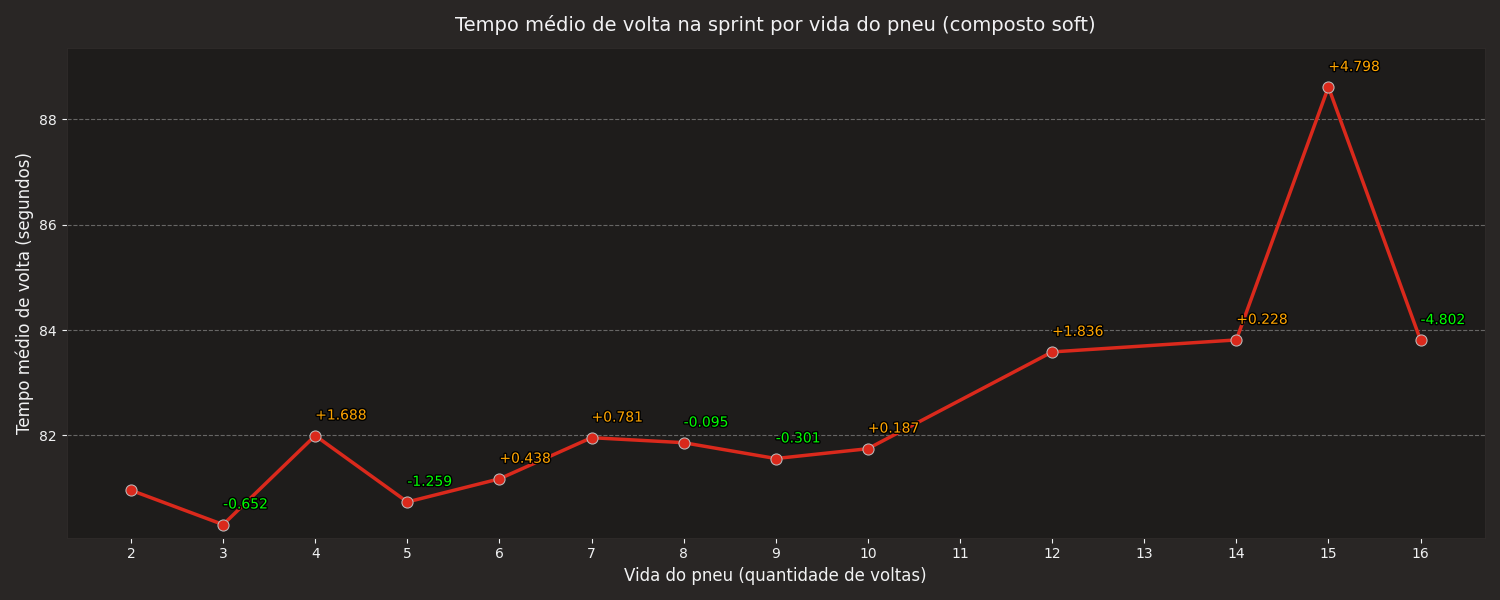

In [52]:
mean_laps_by_life_soft_all_sessions = get_tyre_life_stats(soft)
plot_average_lap_time_by_tyre_wear(
    mean_laps_by_life_soft_all_sessions,
    "Soft",
    sprint,
    language="pt",
)

Esse gráfico ilustra grandes quedas de performance, que parecem se agravar a partir da volta 10. Os intervalos são bem mais agressivos que os outros compostos, variando numa ordem de segundos.

Perceba que enquanto o desvio padrão para outros compostos é medido em milissegundos, para pneus macios, é medido em segundos!

In [53]:
print(
    f"Hard: {hard_mean_laps_by_life.LapTime_s.std():.3f}\n"
    f"Medium: {mean_laps_by_life_medium.LapTime_s.std():.3f}\n",
    f"Soft: {mean_laps_by_life_soft.LapTime_s.std():.3f}",
)

Hard: 0.231
Medium: 0.545
 Soft: 2.046


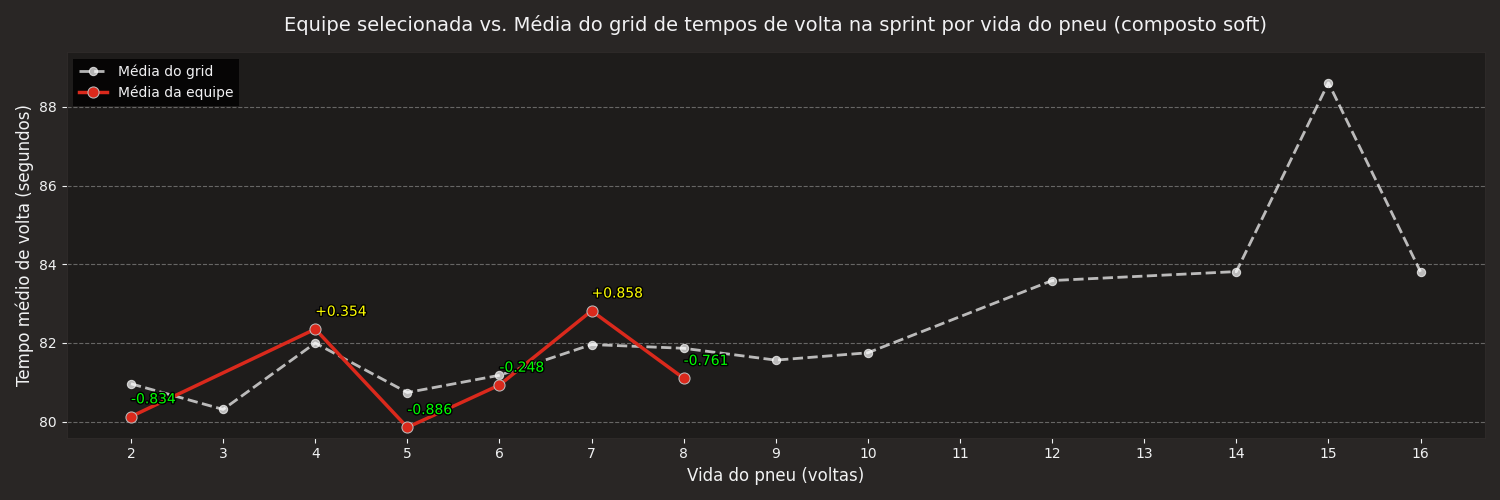

In [54]:
team_mean_laps_by_life_soft = get_tyre_life_stats(soft.pick_teams(TEAM))
plot_team_vs_grid_tyre_wear(
    mean_laps_by_life_soft_all_sessions,
    team_mean_laps_by_life_soft,
    "SOFT",
    sprint,
    language="pt",
)

Adicionalmente, a performance da nossa equipe em pneus macios é visualmente consistente com os outros times, diferentemente dos pneus médios e duros.

## 💡 Resumo e conclusões

### 🕒 Lap Time Distribution

Lap times across all compounds are not normally distributed according to Shapiro-Wilk hypothesis tests, which is expected behaviour in motorsport where cars operate near physical limits. This means non-parametric statistical tests (Mann-Whitney U and Kolmogorov-Smirnov) had to be used throughout the analysis.

### ⚡️ Speed Metrics

**Speed through Intermediate 1 (SpeedI1)** was identified as the most important on-track metric — significantly correlated with lap time across all compounds. As expected, upon visual inspection, it mirrors the lap time distribution inversely.

### 🛞 Tyre compound analysis

🟡 Medium Tyres
- Optimal performance window: **laps 8–15**.
- Strongest correlations with lap time: session type (−0.93/+0.93), SpeedI1 (−0.92), position (0.81), tyre life (0.63).
- The main statistically significant differentiator between teams on mediums is consistency (distribution shape), not raw pace (median/mean) — most teams have statistically indistinguishable central locations.
- Our team on mediums: average lap 84.75s ± 0.36s vs. grid's 86.17s ± 0.55s — faster and more consistent.
- Keep in mind that SpeedI1 has the highest correlation (-0.72) to lap times in this circuit, as analyzed in `circuit_analysis.ipynb`. This is maximized while using medium tyres (-0.92).

⚪ Hard Tyres
- Optimal performance window: the interval of lap time does not vary much, but the grid trend is of slowly diminishing performance after 5 laps, while our team's trend is of slowly increasing performance up until 14 laps.
- Less tyre life sensitivity: TyreLife correlation is of only 0.05 with lap time.
- SpeedI1 remains important (−0.66).
- Hard tyres show **0.315s less standard deviation** than mediums — more predictable degradation.
- Our team on hards: 84.96s ± 0.21s vs. grid's 85.72s ± 0.23s — **faster and slightly more consistent**, with a notably different (favorable) trend between laps 7–12.

🔴 Soft Tyres
- Concentrated on low tyre life ranges with fast lap times — primarily a qualifying compound.
- Performance degrades sharply from lap 10, with standard deviation of 2.17s (vs. 0.54s for medium and 0.23s for hard) — highly variable, sharp decline in performance.
- Our team's soft tyre performance is similar to the rest of the grid — no meaningful advantage here, unlike on the other two compounds.

### 🏁 Overall strategic insights

1. Intermediate 1 is the circuit's most critical sector — teams should focus setup and driving style on maximizing speed through the first intermediate sector.
2. Medium tyres are the sweet spot: our team has a clear pace and consistency advantage on them, making them the preferred race compound.
3. Hard tyres offer stability for long stints with lower degradation variance, and our team also has an edge on them.
4. Soft tyres should be used sparingly in the race — high degradation variance and no clear advantage make them a risk over longer stints.
5. Consistency over raw pace is the key differentiating factor in lap times — the KS test confirmed that distribution shape (variance) separates teams more than their median lap times.

## 🌱 Future works and improvements